# CCS3440 – Artificial Intelligence Coursework
## SmartCare Hospital AI Dataset — Option C: Disease Risk Classification

**Problem:** Predict a patient's disease risk category (`Low`, `Medium`, `High`) — a multi-class
classification problem — from demographic, clinical, and operational data.

This notebook covers Tasks 02–08 of the coursework specification:
Dataset Understanding, Preprocessing & Feature Engineering, EDA, Model Development,
Model Evaluation, Explainable AI, and the basis for the AI Prototype.


## 2.1 Import library and Load Data set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Read the dataset
df = pd.read_csv('/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_1000.csv')

print("Dataset loaded successfully!")
df.head()

Mounted at /content/drive
Dataset loaded successfully!


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 2.6 Load and Display the Data Dictionary

In [ ]:
data_dictionary = pd.read_csv(
    '/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_data_dictionary.csv'
)

data_dictionary

,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


# **Task 3 - Data Preprocessing and Feature Engineering**

## 3.1 Import Required Libraries


This section imports all the required Python libraries used for data preprocessing, feature engineering, visualization, and machine learning.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

## 3.2 Load Dataset

The SmartCare Hospital dataset is loaded into a Pandas DataFrame for preprocessing and analysis.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_1000.csv")

df.head()

,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3.3 Dataset Overview

Before cleaning the dataset, it is important to understand its structure, number of records, data types, and basic information.

In [ ]:
df.shape

(1000, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

In [ ]:
df.describe()

,record_id,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,no_show,readmitted_30_days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.744000,21.851000,2.884000,0.553000,0.330000,1.103000,0.85500,128.423000,78.828000,114.832000,204.814000,25.519100,2.292000,1.805000,2820.500000,2412.50000,4869.600000,7971.000000,18073.600000,0.495000,0.253000
std,288.819436,17.851474,13.040892,1.693343,0.740094,0.470448,1.885191,0.95859,15.486895,10.043669,26.017007,36.645577,4.252852,1.679749,1.596723,837.694146,11140.88026,4122.515127,4629.777041,13710.258789,0.500225,0.434948
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,85.000000,50.000000,65.000000,100.000000,14.000000,0.000000,0.000000,1500.000000,0.00000,0.000000,506.000000,2954.000000,0.000000,0.000000
25%,250.750000,33.000000,11.000000,2.000000,0.000000,0.000000,0.000000,0.00000,117.000000,72.000000,97.000000,180.000000,22.700000,1.000000,1.000000,2000.000000,0.00000,2400.000000,4316.500000,11018.000000,0.000000,0.000000
50%,500.500000,44.000000,22.000000,3.000000,0.000000,0.000000,0.000000,1.00000,128.000000,79.000000,114.000000,204.000000,25.600000,2.000000,1.000000,3000.000000,0.00000,3600.000000,7680.000000,15068.500000,0.000000,0.000000
75%,750.250000,57.000000,34.000000,4.000000,1.000000,1.000000,2.000000,1.00000,139.000000,86.000000,132.000000,230.000000,28.300000,3.000000,3.000000,3500.000000,0.00000,6300.000000,11032.000000,20870.000000,1.000000,1.000000
max,1000.000000,90.000000,44.000000,10.000000,4.000000,1.000000,9.000000,5.00000,178.000000,111.000000,201.000000,330.000000,38.800000,10.000000,10.000000,4000.000000,150000.00000,27000.000000,20371.000000,179528.000000,1.000000,1.000000


## 3.4 Handling Missing Values

Missing values can reduce model performance. Therefore, missing numerical values were replaced using the median, while categorical values were replaced using the mode.

In [ ]:
df.isnull().sum()

,0
record_id,0
patient_id,0
age,0
gender,0
blood_group,0
department,0
diagnosis,0
appointment_date,0
waiting_days,0
previous_appointments,0


If values exist

Missing numerical values were replaced using the median because it is less sensitive to outliers. Categorical values were replaced using the most frequent value (mode).

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

In [ ]:
df.isnull().sum()

,0
record_id,0
patient_id,0
age,0
gender,0
blood_group,0
department,0
diagnosis,0
appointment_date,0
waiting_days,0
previous_appointments,0


## 3.5 Duplicate Record Detection

Duplicate records may negatively affect model performance by introducing bias.

In [ ]:
df.duplicated().sum()

np.int64(0)

## 3.6 Outlier Identification

Boxplots are used to identify potential outliers in numerical attributes.

In [ ]:
# Outlier Identify with numerical
num_cols = ['age','waiting_days','previous_appointments','missed_previous_appointments',
            'length_of_stay_days','previous_admissions','systolic_bp','diastolic_bp',
            'blood_sugar_mg_dl','cholesterol_mg_dl','bmi','lab_tests_count',
            'treatments_count','total_bill_lkr']

outlier_summary = {}
for c in num_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary[c] = n_out

pd.Series(outlier_summary, name='n_outliers').sort_values(ascending=False)

,n_outliers
previous_admissions,60
total_bill_lkr,59
length_of_stay_days,48
lab_tests_count,23
missed_previous_appointments,17
treatments_count,17
blood_sugar_mg_dl,10
bmi,9
previous_appointments,8
cholesterol_mg_dl,6


BMI

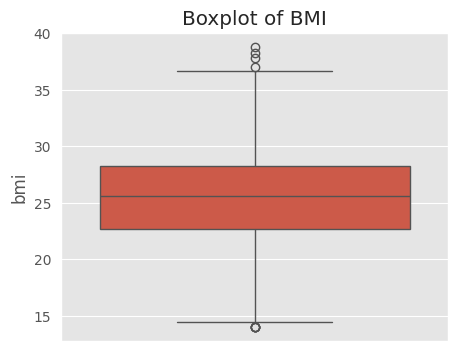

In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["bmi"])
plt.title("Boxplot of BMI")
plt.show()

Blood Sugar

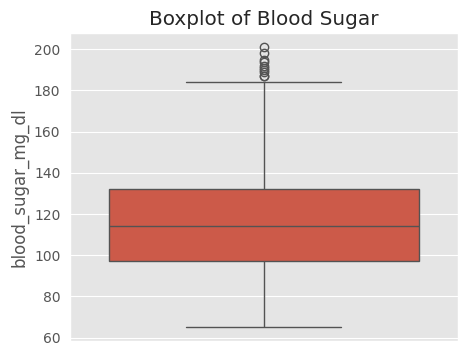

In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["blood_sugar_mg_dl"])
plt.title("Boxplot of Blood Sugar")
plt.show()

Cholesterol

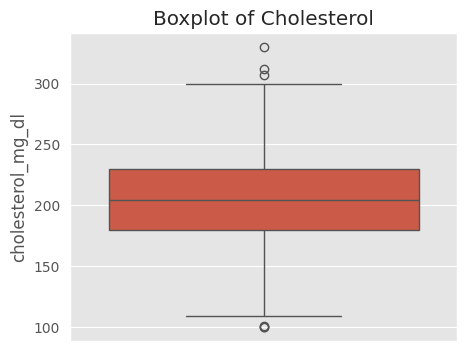

In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["cholesterol_mg_dl"])
plt.title("Boxplot of Cholesterol")
plt.show()

Age

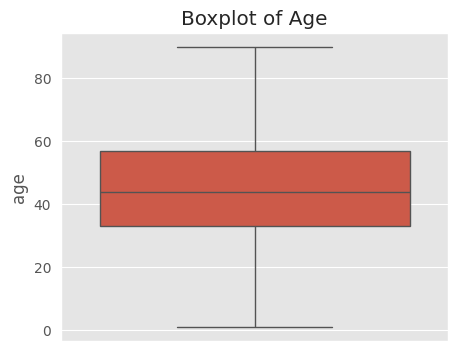

In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["age"])
plt.title("Boxplot of Age")
plt.show()

Boxplots indicate a few extreme observations in some numerical features. These values may represent genuine patient conditions rather than data errors; therefore, they should only be removed if there is clear evidence that they are incorrect.

## 3.7 Data Cleaning Summary

The dataset was checked for missing values, duplicate records, and outliers before model development.

Data cleaning improves dataset quality and ensures that the machine learning models learn from reliable data.

## 3.8 Feature Encoding

Machine learning algorithms require numerical input. Therefore, categorical variables were converted into numerical values using Label Encoding.

In [ ]:
encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

All categorical attributes were successfully transformed into numerical values suitable for machine learning algorithms.

## 3.9 Feature Scaling

Feature scaling standardizes numerical variables so that features with larger values do not dominate the learning process.

In [ ]:
scaler = StandardScaler()

num_cols = df.drop("disease_risk_level", axis=1).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

Standardization transformed numerical variables to a common scale with mean approximately zero and standard deviation one. This benefits algorithms such as Logistic Regression and Support Vector Machines.

## 3.10 Feature Selection

Input features and the target variable were separated before model training.

In [ ]:
X = df.drop("disease_risk_level", axis=1)

y = df["disease_risk_level"]

The target variable is disease_risk_level, while all remaining columns are used as input features.

## 3.11 Feature Engineering

Feature engineering creates meaningful variables that improve model performance.

In [ ]:
df["BMI_Category"] = pd.cut(
    df["bmi"],
    bins=[0,18.5,25,30,100],
    labels=["Underweight","Normal","Overweight","Obese"]
)

A new BMI category feature was created to group patients according to standard BMI ranges, making it easier for machine learning models to identify health-related patterns.

# **Task 04 – Exploratory Data Analysis bold text**

## 4.1 Descriptive Statistics
Descriptive statistics provide an overview of the central tendency and variation of numerical attributes.


In [ ]:
df.describe()

,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
count,1000.00000,1000.00000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.00000
mean,0.00000,0.00000,1.421085e-17,-5.861978e-17,-8.881784e-18,7.815970e-17,1.021405e-17,-4.085621e-17,7.371881e-17,7.638334e-17,-3.197442e-17,-7.815970e-17,4.440892e-18,2.486900e-17,7.904788e-17,-3.552714e-18,-1.243450e-16,-3.010925e-16,2.442491e-16,1.909584e-16,4.369838e-16,9.947598e-17,4.796163e-17,1.776357e-18,2.486900e-17,-9.237056e-17,3.552714e-18,1.101341e-16,-1.172396e-16,7.815970e-17,-5.329071e-18,4.973799e-17,1.06900
std,1.00050,1.00050,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,0.93011
min,-1.73032,-1.73032,-2.451668e+00,-1.002002e+00,-1.515730e+00,-1.442672e+00,-1.598598e+00,-1.698130e+00,-1.676414e+00,-1.703992e+00,-7.475765e-01,-2.259718e+00,-7.018100e-01,-2.038412e-01,-5.853794e-01,-8.923818e-01,-2.805257e+00,-2.871702e+00,-1.916321e+00,-2.861640e+00,-2.709914e+00,-1.365172e+00,-1.131006e+00,-1.577140e+00,-2.166532e-01,-1.181812e+00,-1.613195e+00,-1.103346e+00,-6.635805e-01,-1.365521e+00,-9.900495e-01,-5.819691e-01,0.00000
25%,-0.86516,-0.86516,-6.582020e-01,-1.002002e+00,-1.078668e+00,-9.501242e-01,-9.073124e-01,-8.438476e-01,-8.324913e-01,-5.223054e-01,-7.475765e-01,-8.349273e-01,-7.018100e-01,-2.038412e-01,-5.853794e-01,-8.923818e-01,-7.379604e-01,-6.801714e-01,-6.857408e-01,-6.774737e-01,-6.632045e-01,-7.695473e-01,-5.044098e-01,-9.799645e-01,-2.166532e-01,-5.993515e-01,-7.897418e-01,-5.148794e-01,-6.635805e-01,-4.594022e-01,-9.900495e-01,-5.819691e-01,0.00000
50%,0.00000,0.00000,-4.169808e-02,9.980020e-01,-2.045448e-01,3.497088e-02,1.296161e-01,-2.526637e-02,1.143132e-02,6.853781e-02,-7.475765e-01,5.898633e-01,-7.018100e-01,-2.038412e-01,-5.853794e-01,1.513396e-01,-2.732708e-02,1.713378e-02,-3.199508e-02,-2.222389e-02,1.903205e-02,-1.739225e-01,-5.044098e-01,2.143859e-01,-2.166532e-01,-3.081214e-01,-6.288545e-02,-2.192959e-01,-6.635805e-01,4.467165e-01,-9.900495e-01,-5.819691e-01,1.00000
75%,0.86516,0.86516,6.868975e-01,9.980020e-01,6.695784e-01,1.020066e+00,8.209017e-01,8.621675e-01,9.320742e-01,6.593810e-01,6.042798e-01,5.898633e-01,1.424887e+00,-2.038412e-01,4.760520e-01,1.513396e-01,6.833063e-01,7.144390e-01,6.602062e-01,6.876301e-01,6.542178e-01,4.217024e-01,7.487823e-01,8.115611e-01,-2.166532e-01,3.471463e-01,6.614858e-01,2.040661e-01,5.562366e-01,4.467165e-01,1.010051e+00,1.718304e+00,2.00000
max,1.73032,1.73032,2.536409e+00,9.980020e-01,1.543702e+00,1.512614e+00,1.512187e+00,1.749601e+00,1.699277e+00,4.204440e+00,4.659849e+00,2.014654e+00,1.424887e+00,5.231925e+00,4.191062e+00,4.326225e+00,3.202825e+00,3.204815e+00,3.313645e+00,3.417838e+00,3.124384e+00,4.591076e+00,5.134955e+00,1.408736e+00,1.325401e+01,5.370865e+00,2.679655e+00,1.178207e+01,1.776054e+00,1.352835e+00,1.010051e+00,1.718304e+00,2.00000


## 4.2 Class Distribution

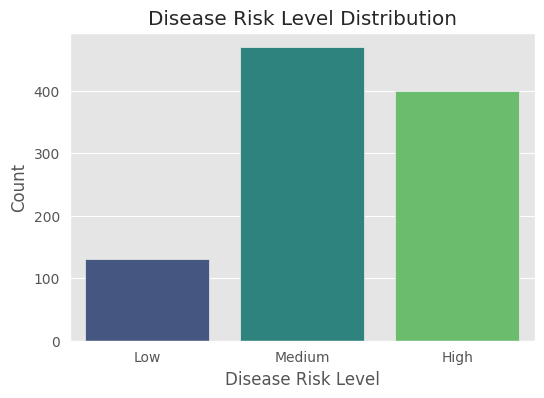

In [ ]:
plt.figure(figsize=(6,4))

# Define the label map based on target_encoder.classes_
# The target_encoder.classes_ are ['High', 'Low', 'Medium'], so numeric 0=High, 1=Low, 2=Medium
label_map = {0: 'High', 1: 'Low', 2: 'Medium'}
df['risk_level_label'] = df['disease_risk_level'].map(label_map)

sns.countplot(x="risk_level_label", data=df, order=['Low','Medium','High'],
              palette='viridis')
plt.title("Disease Risk Level Distribution")
plt.xlabel("Disease Risk Level")
plt.ylabel("Count")
plt.show()

This chart illustrates the number of patients in each disease risk category. A balanced class distribution is beneficial for machine learning.

## 4.3 Histograms

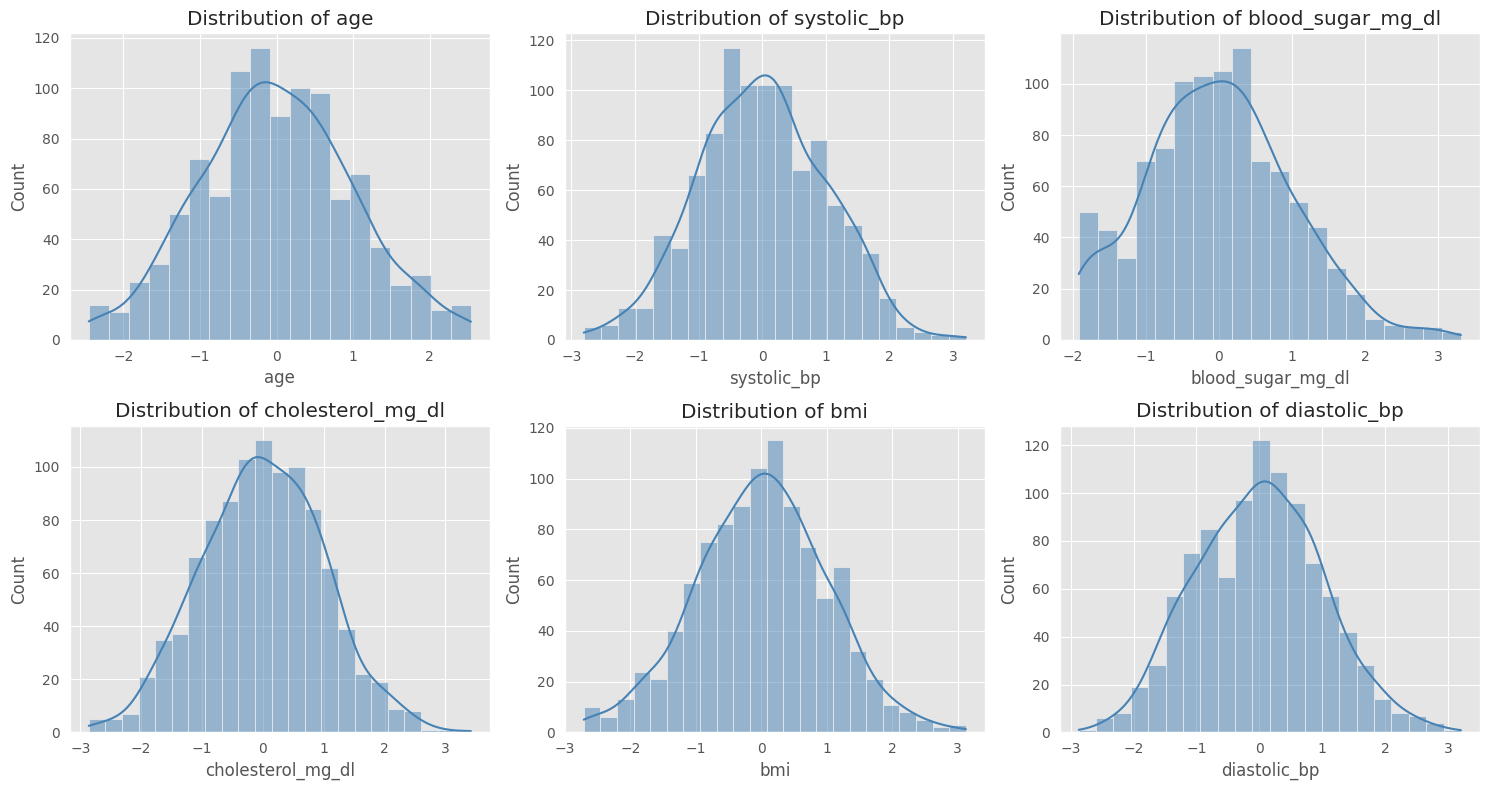

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hist_cols = ['age', 'systolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'diastolic_bp']
for ax, col in zip(axes.flatten(), hist_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Histograms show the distribution of numerical variables and help identify skewness and unusual patterns.

## 4.4 Boxplots

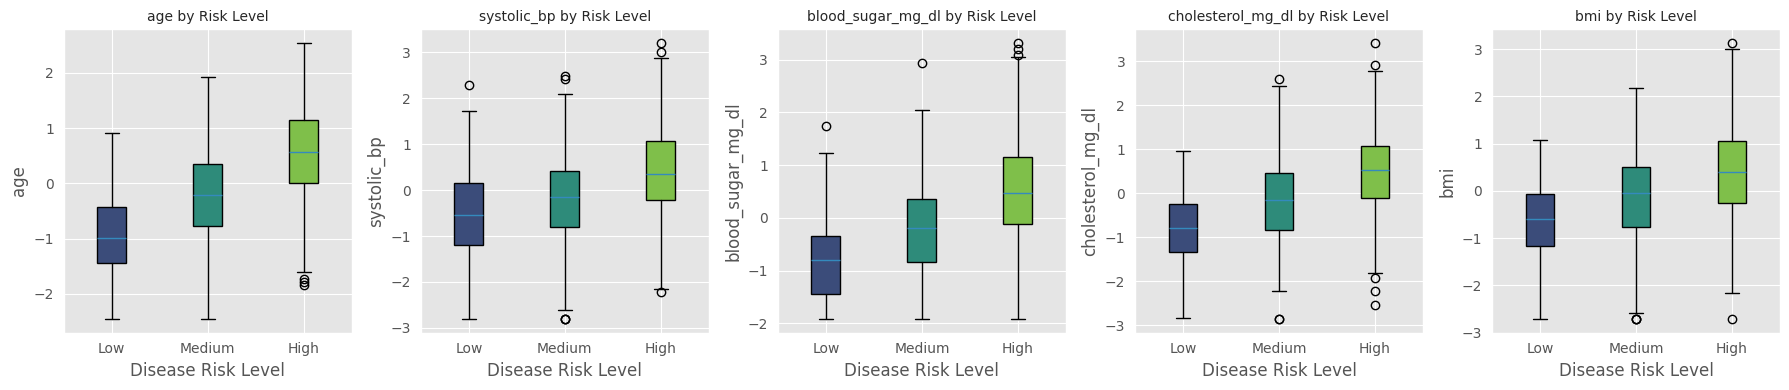

In [ ]:
label_map = {0: 'High', 1: 'Low', 2: 'Medium'}
df['risk_level_label'] = df['disease_risk_level'].map(label_map)

colors = ['#3B4C7A', '#2E8B7A', '#7FBF4A']  # Low, Medium, High

box_cols = ['age', 'systolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, box_cols):
    data_by_group = [df[df['risk_level_label'] == level][col].dropna()
                      for level in ['Low', 'Medium', 'High']]
    bp = ax.boxplot(data_by_group, tick_labels=['Low', 'Medium', 'High'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_title(f'{col} by Risk Level', fontsize=10)
    ax.set_xlabel('Disease Risk Level')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

Patients with higher BMI values appear more frequently in the high disease risk category, suggesting a possible relationship.

## 4.5 Scatterplots

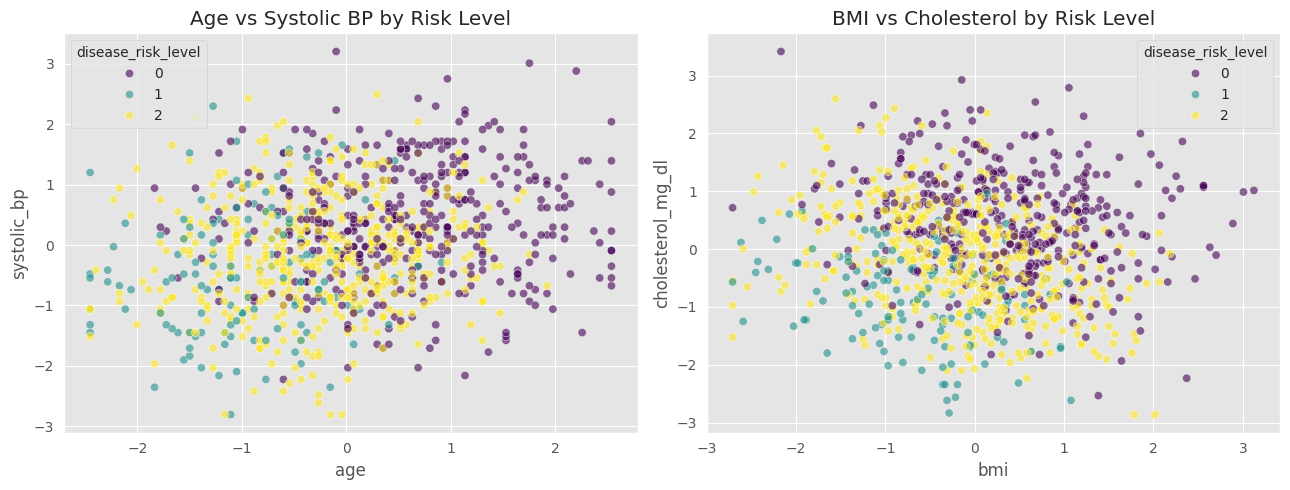

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='age', y='systolic_bp', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Systolic BP by Risk Level')

sns.scatterplot(data=df, x='bmi', y='cholesterol_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('BMI vs Cholesterol by Risk Level')
plt.tight_layout()
plt.show()

Patients with higher BMI and blood sugar values tend to belong to higher disease risk groups.

## 4.6 Correlation Heatmap

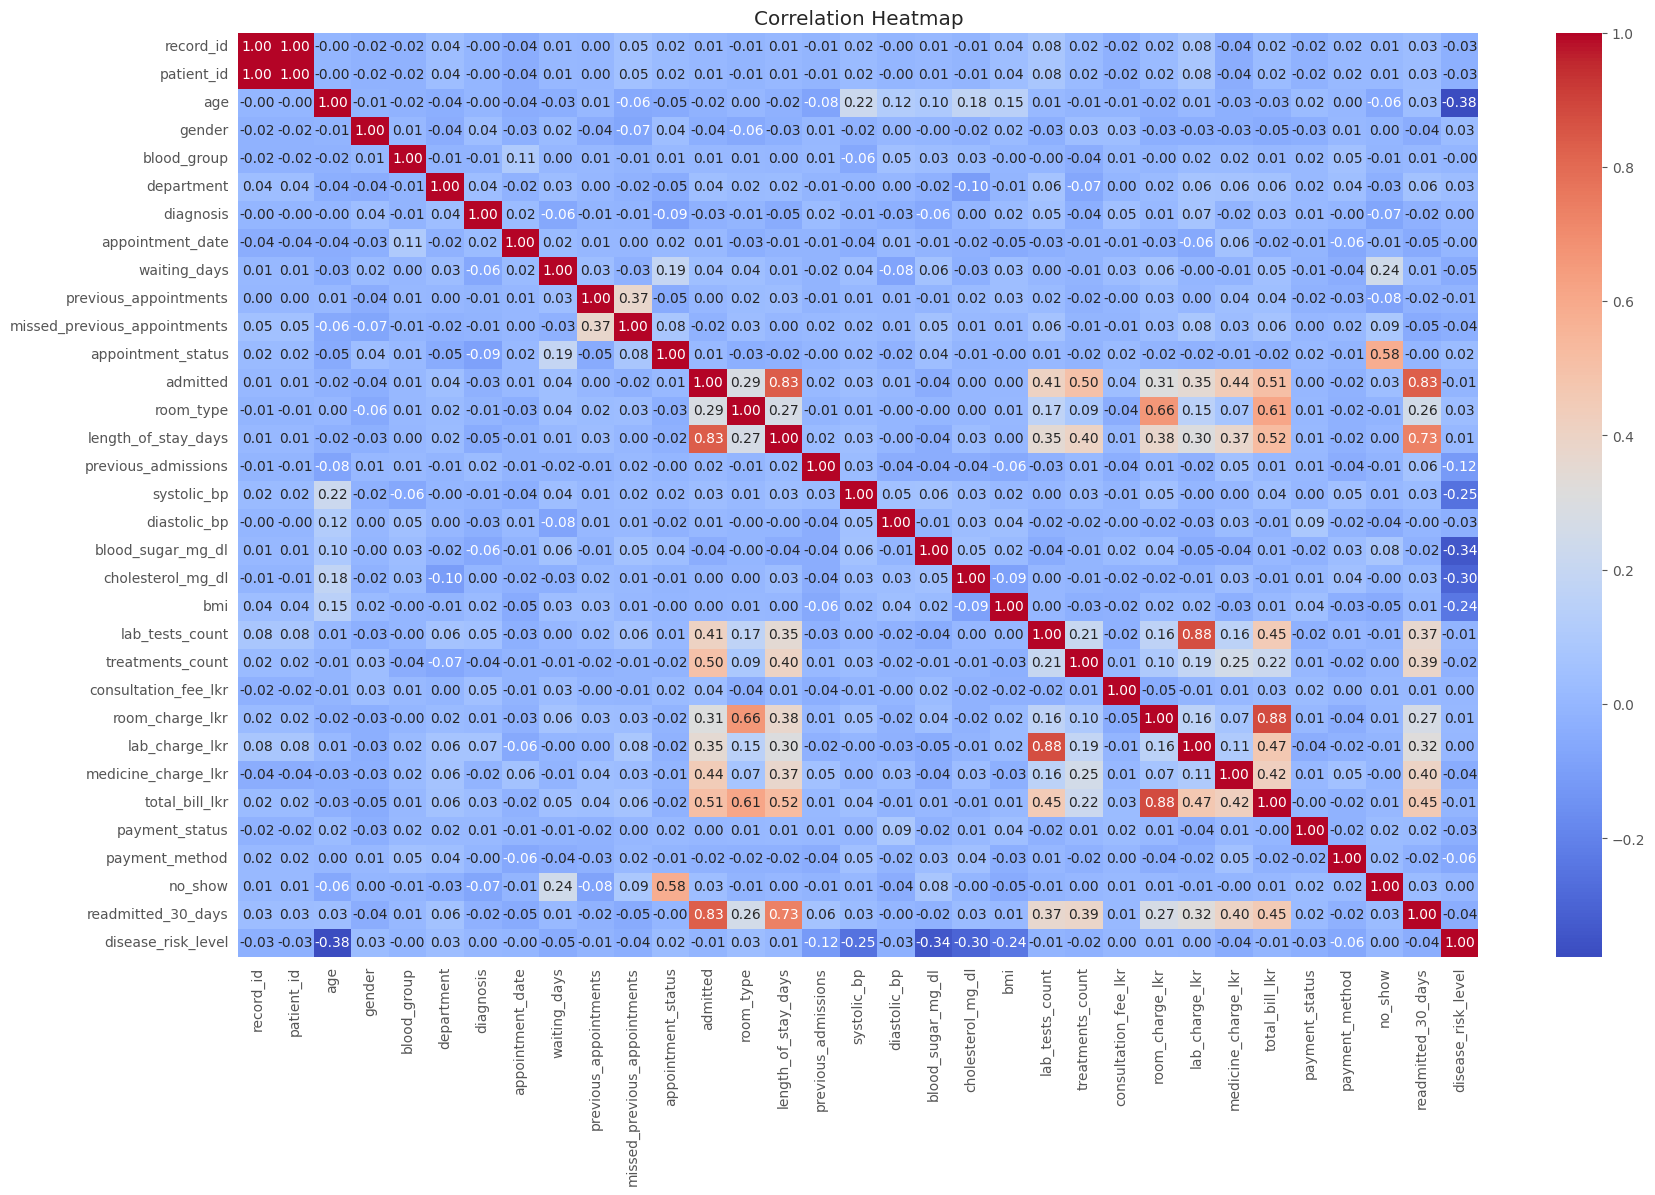

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(20,12))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

The heatmap highlights relationships between numerical variables. Features with stronger correlations may have greater influence on disease risk prediction.

## 4.7 Key Findings from EDA

The dataset is generally clean and suitable for machine learning after preprocessing.
The High Disease Risk category contains the largest number of patients, while the Medium Risk category has the fewest.
Most numerical features, such as age, BMI, blood sugar, and cholesterol, follow a reasonable distribution with only a few outliers.
BMI, blood sugar, and cholesterol show noticeable differences across disease risk groups, indicating they may be important predictors.
Financial variables (room charges, laboratory charges, medicine charges, and total bill) are positively correlated with each other.
The scatter plot shows that disease risk cannot be explained by a single feature, highlighting the need for machine learning models that consider multiple patient attributes.
Overall, the EDA identified meaningful patterns and relationships that support the development of an accurate disease risk classification model.

## 4.8 Summary of Preprocessing and EDA
The dataset was successfully prepared for machine learning by handling missing values, checking duplicate records, detecting outliers, encoding categorical variables, scaling numerical features, and creating engineered features. Exploratory Data Analysis provided insights into data distribution and relationships between important clinical variables and disease risk. The processed dataset is now ready for model development.
